# Plots
## Universidad ICESI 
### David Mauricio Orozco Rios
### author: Davoroz06 - IG

In [1]:
# libraries
import pandas as pd
import numpy as np
import os
from datetime import datetime
from scipy.stats import gmean
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as st

# options for data display
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)

# project paths and shared helpers (see src/config.py)
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(ROOT / "src"))
from config import *  # wd, wd_dp, wd_db, wd_dpr, wd_re, wd_rp, wd_rt ...
from utils import homogenize_text


In [2]:
regular_window = 7
reference_window = 7
case = "Comparison"

In [ ]:
# figures are saved in one folder per specification
spec = "{}_{}_{}".format(case, regular_window, reference_window)
fig_dir = wd_rp + {"Comparison_7_7": "main", "All_7_7": "robustness_full_sample",
                   "Comparison_14_30": "annex_biweekly_monthly"}.get(spec, spec) + "/"
os.makedirs(fig_dir, exist_ok=True)

## Load data:

In [3]:
# load retailer data
data = pd.read_excel(wd_re + "Price_Setting_{}_{}_{}.xlsx".format(case, regular_window, reference_window))

In [4]:
data_clas = pd.read_excel(wd_data + "product_classification.xlsx")

In [5]:
data = data.merge(data_clas, left_on='descripcion', right_on='Descripcion', how='left')

In [6]:
data = data.drop(["Descripcion", 'Code'], axis = 1)

In [7]:
data.columns

Index(['tienda', 'descripcion', 'Price Change Fr', 'Price Implied Duration',
       'Price Change Si', 'Price Change Di', 'RPE Change Fr',
       'RPE Implied Duration', 'RPE Change Si', 'RPE Change Di',
       'RPN Change Fr', 'RPN Implied Duration', 'RPN Change Si',
       'RPN Change Di', 'Group'],
      dtype='object')

In [8]:
data.Group.unique()

array(['Food And Non-Alcoholic Beverages',
       'Alcoholic Beverages, Tobacco And Narcotics',
       'Recreation, Sport And Culture', 'Health',
       'Personal Care, Social Protection And Miscellaneous Goods And Services',
       'Furnishings, Household Equipment And Routine Household Maintenance',
       'Information And Communication', 'Transport',
       'Clothing And Footwear'], dtype=object)

In [9]:
data.columns

Index(['tienda', 'descripcion', 'Price Change Fr', 'Price Implied Duration',
       'Price Change Si', 'Price Change Di', 'RPE Change Fr',
       'RPE Implied Duration', 'RPE Change Si', 'RPE Change Di',
       'RPN Change Fr', 'RPN Implied Duration', 'RPN Change Si',
       'RPN Change Di', 'Group'],
      dtype='object')

In [10]:
data['tienda'].unique()

array(['C', 'A1', 'A2', 'B'], dtype=object)

In [11]:
# stores are already anonymized in the data (A1, A2: multichannel supermarkets; B: price-comparison platform; C: hard-discount store)

In [12]:
data['tienda'].unique()

array(['C', 'A1', 'A2', 'B'], dtype=object)

## Violin plot - Price Change Freq distribution across stores

Text(0.5, 0, 'Store')

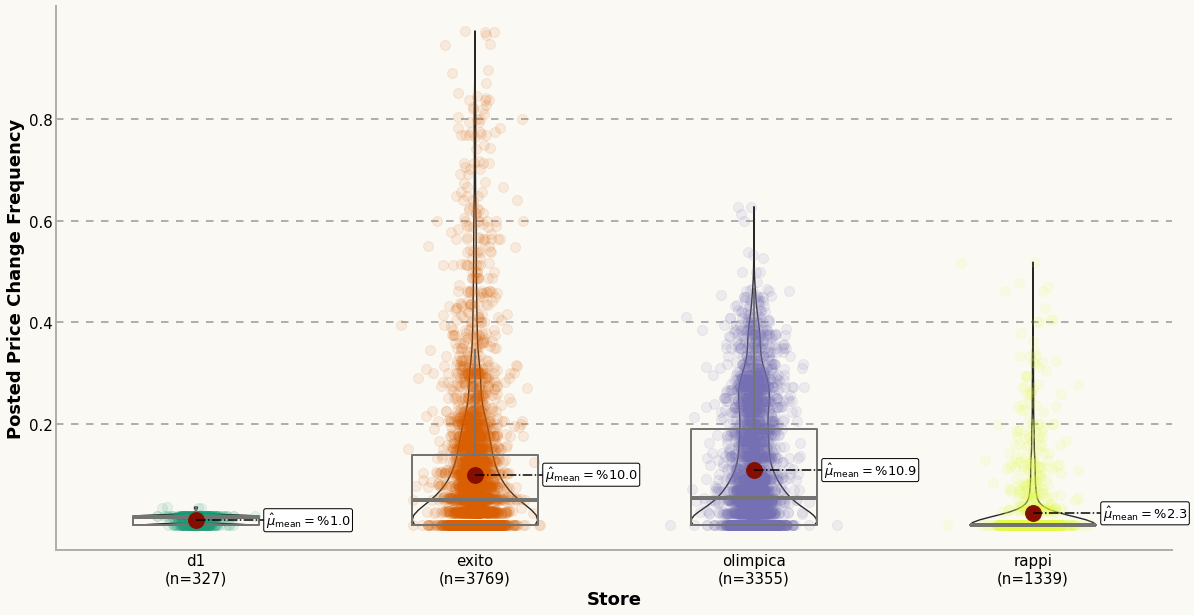

In [43]:
# Get the species, sorted alphabetically
tiendas = sorted(data["tienda"].unique())

# y_data is a list of length 3 containing the bill_length_mm values for each specie 
y_data = [data[data["tienda"] == tienda]["Price Change Fr"].values for tienda in tiendas]

# Create jittered version of "x" (which is only 0, 1, and 2)
# More about this in the bonus track!
jitter = 0.04
x_data = [np.array([i] * len(d)) for i, d in enumerate(y_data)]
x_jittered = [x + st.t(df=6, scale=jitter).rvs(len(x)) for x in x_data]

# Colors
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"

# Colors taken from Dark2 palette in RColorBrewer R library
COLOR_SCALE = ["#1B9E77", "#D95F02", "#7570B3", "#e5fb45"]

# Horizontal positions for the violins. 
# They are arbitrary numbers. They could have been [-1, 0, 1] for example.
POSITIONS = [0, 1, 2, 3]

# Horizontal lines
HLINES = [0.2, 0.4, 0.6, 0.8]

fig, ax = plt.subplots(figsize= (20, 10))

# Some layout stuff ----------------------------------------------
# Background color
fig.patch.set_facecolor(BG_WHITE)
ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)

# Add violins ----------------------------------------------------
# bw_method="silverman" means the bandwidth of the kernel density
# estimator is computed via Silverman's rule of thumb. 
# More on this in the bonus track ;)

# The output is stored in 'violins', used to customize their appearence
violins = ax.violinplot(
    y_data, 
    positions=POSITIONS,
    widths=0.45,
    bw_method="silverman",
    showmeans=False, 
    showmedians=False,
    showextrema=False
)

# Customize violins (remove fill, customize line, etc.)
for pc in violins["bodies"]:
    pc.set_facecolor("none")
    pc.set_edgecolor(BLACK)
    pc.set_linewidth(1.4)
    pc.set_alpha(1)
    

# Add boxplots ---------------------------------------------------
# Note that properties about the median and the box are passed
# as dictionaries.

medianprops = dict(
    linewidth=4, 
    color=GREY_DARK,
    solid_capstyle="butt"
)
boxprops = dict(
    linewidth=2, 
    color=GREY_DARK
)

ax.boxplot(
    y_data,
    positions=POSITIONS, 
    showfliers = False, # Do not show the outliers beyond the caps.
    showcaps = False,   # Do not show the caps
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops
)

# Add jittered dots ----------------------------------------------
for x, y, color in zip(x_jittered, y_data, COLOR_SCALE):
    ax.scatter(x, y, s = 100, color=color, alpha=0.1)
    
# Add mean value labels ------------------------------------------
means = [y.mean() for y in y_data]
for i, mean in enumerate(means):
    # Add dot representing the mean
    ax.scatter(i, mean, s=250, color=RED_DARK, zorder=3)
    
    # Add line conecting mean value and its label
    ax.plot([i, i + 0.25], [mean, mean], ls="dashdot", color="black", zorder=3)
    
    # Add mean value label.
    ax.text(
        i + 0.25,
        mean,
        r"$\hat{\mu}_{\rm{mean}} = \%$" + str(round(mean*100, 1)),
        fontsize=13,
        va="center",
        bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),
        zorder=10 # to make sure the line is on top
    )

# Customize layout -----------------------------------------------
# Hide spines
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")

# Customize spines color
ax.spines["left"].set_color(GREY_LIGHT)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_color(GREY_LIGHT)
ax.spines["bottom"].set_linewidth(2)

# Customize labels and ticks
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=15)
ax.set_ylabel("Posted Price Change Frequency", size=18, weight="bold")

# xlabels accounts for the sample size for each species
xlabels = [f"{tienda}\n(n={y_data[i].size})" for i, tienda in enumerate(tiendas)]
ax.set_xticks(POSITIONS)
ax.set_xticklabels(xlabels, size=15, ha="center", ma="center")
ax.set_xlabel("Store", size=18, weight="bold")

In [44]:
# Save the plot as a high-resolution image (optional)
fig.savefig(fig_dir + 'violin_change_frequency_posted.png', dpi=300, bbox_inches='tight')

Text(0.5, 0, 'Store')

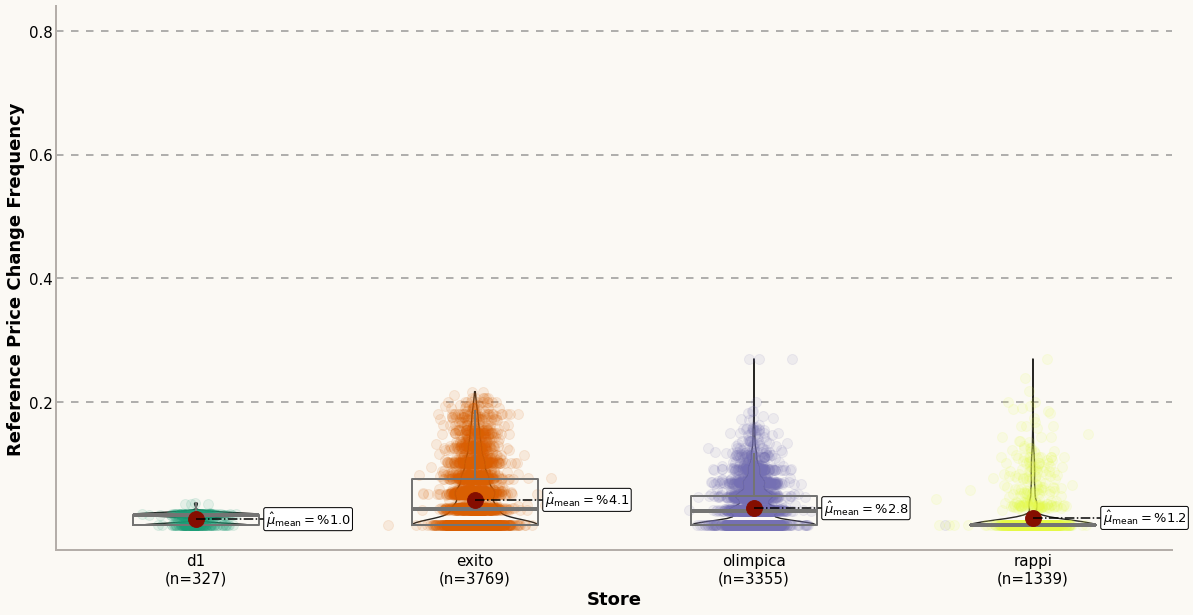

In [45]:
# Get the species, sorted alphabetically
tiendas = sorted(data["tienda"].unique())

# y_data is a list of length 3 containing the bill_length_mm values for each specie 
y_data = [data[data["tienda"] == tienda]["RPE Change Fr"].values for tienda in tiendas]

# Create jittered version of "x" (which is only 0, 1, and 2)
# More about this in the bonus track!
jitter = 0.04
x_data = [np.array([i] * len(d)) for i, d in enumerate(y_data)]
x_jittered = [x + st.t(df=6, scale=jitter).rvs(len(x)) for x in x_data]

# Colors
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"

# Colors taken from Dark2 palette in RColorBrewer R library
COLOR_SCALE = ["#1B9E77", "#D95F02", "#7570B3", "#e5fb45"]

# Horizontal positions for the violins. 
# They are arbitrary numbers. They could have been [-1, 0, 1] for example.
POSITIONS = [0, 1, 2, 3]

# Horizontal lines
HLINES = [0.2, 0.4, 0.6, 0.8]

fig, ax = plt.subplots(figsize= (20, 10))

# Some layout stuff ----------------------------------------------
# Background color
fig.patch.set_facecolor(BG_WHITE)
ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)

# Add violins ----------------------------------------------------
# bw_method="silverman" means the bandwidth of the kernel density
# estimator is computed via Silverman's rule of thumb. 
# More on this in the bonus track ;)

# The output is stored in 'violins', used to customize their appearence
violins = ax.violinplot(
    y_data, 
    positions=POSITIONS,
    widths=0.45,
    bw_method="silverman",
    showmeans=False, 
    showmedians=False,
    showextrema=False
)

# Customize violins (remove fill, customize line, etc.)
for pc in violins["bodies"]:
    pc.set_facecolor("none")
    pc.set_edgecolor(BLACK)
    pc.set_linewidth(1.4)
    pc.set_alpha(1)
    

# Add boxplots ---------------------------------------------------
# Note that properties about the median and the box are passed
# as dictionaries.

medianprops = dict(
    linewidth=4, 
    color=GREY_DARK,
    solid_capstyle="butt"
)
boxprops = dict(
    linewidth=2, 
    color=GREY_DARK
)

ax.boxplot(
    y_data,
    positions=POSITIONS, 
    showfliers = False, # Do not show the outliers beyond the caps.
    showcaps = False,   # Do not show the caps
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops
)

# Add jittered dots ----------------------------------------------
for x, y, color in zip(x_jittered, y_data, COLOR_SCALE):
    ax.scatter(x, y, s = 100, color=color, alpha=0.1)
    
# Add mean value labels ------------------------------------------
means = [y.mean() for y in y_data]
for i, mean in enumerate(means):
    # Add dot representing the mean
    ax.scatter(i, mean, s=250, color=RED_DARK, zorder=3)
    
    # Add line conecting mean value and its label
    ax.plot([i, i + 0.25], [mean, mean], ls="dashdot", color="black", zorder=3)
    
    # Add mean value label.
    ax.text(
        i + 0.25,
        mean,
        r"$\hat{\mu}_{\rm{mean}} = \%$" + str(round(mean*100, 1)),
        fontsize=13,
        va="center",
        bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),
        zorder=10 # to make sure the line is on top
    )

# Customize layout -----------------------------------------------
# Hide spines
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")

# Customize spines color
ax.spines["left"].set_color(GREY_LIGHT)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_color(GREY_LIGHT)
ax.spines["bottom"].set_linewidth(2)

# Customize labels and ticks
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=15)
ax.set_ylabel("Reference Price Change Frequency", size=18, weight="bold")

# xlabels accounts for the sample size for each species
xlabels = [f"{tienda}\n(n={y_data[i].size})" for i, tienda in enumerate(tiendas)]
ax.set_xticks(POSITIONS)
ax.set_xticklabels(xlabels, size=15, ha="center", ma="center")
ax.set_xlabel("Store", size=18, weight="bold")

In [46]:
# Save the plot as a high-resolution image (optional)
fig.savefig(fig_dir + 'violin_change_frequency_reference.png', dpi=300, bbox_inches='tight')

Text(0.5, 0, 'Store')

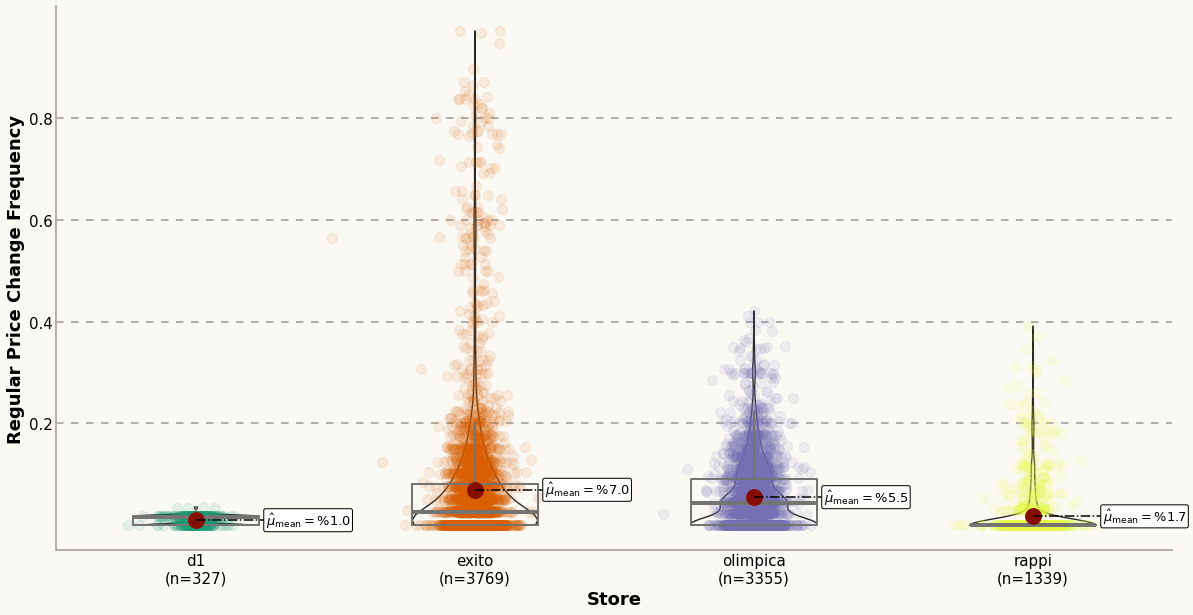

In [47]:
# Get the species, sorted alphabetically
tiendas = sorted(data["tienda"].unique())

# y_data is a list of length 3 containing the bill_length_mm values for each specie 
y_data = [data[data["tienda"] == tienda]["RPN Change Fr"].values for tienda in tiendas]

# Create jittered version of "x" (which is only 0, 1, and 2)
# More about this in the bonus track!
jitter = 0.04
x_data = [np.array([i] * len(d)) for i, d in enumerate(y_data)]
x_jittered = [x + st.t(df=6, scale=jitter).rvs(len(x)) for x in x_data]

# Colors
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"

# Colors taken from Dark2 palette in RColorBrewer R library
COLOR_SCALE = ["#1B9E77", "#D95F02", "#7570B3", "#e5fb45"]

# Horizontal positions for the violins. 
# They are arbitrary numbers. They could have been [-1, 0, 1] for example.
POSITIONS = [0, 1, 2, 3]

# Horizontal lines
HLINES = [0.2, 0.4, 0.6, 0.8]

fig, ax = plt.subplots(figsize= (20, 10))

# Some layout stuff ----------------------------------------------
# Background color
fig.patch.set_facecolor(BG_WHITE)
ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)

# Add violins ----------------------------------------------------
# bw_method="silverman" means the bandwidth of the kernel density
# estimator is computed via Silverman's rule of thumb. 
# More on this in the bonus track ;)

# The output is stored in 'violins', used to customize their appearence
violins = ax.violinplot(
    y_data, 
    positions=POSITIONS,
    widths=0.45,
    bw_method="silverman",
    showmeans=False, 
    showmedians=False,
    showextrema=False
)

# Customize violins (remove fill, customize line, etc.)
for pc in violins["bodies"]:
    pc.set_facecolor("none")
    pc.set_edgecolor(BLACK)
    pc.set_linewidth(1.4)
    pc.set_alpha(1)
    

# Add boxplots ---------------------------------------------------
# Note that properties about the median and the box are passed
# as dictionaries.

medianprops = dict(
    linewidth=4, 
    color=GREY_DARK,
    solid_capstyle="butt"
)
boxprops = dict(
    linewidth=2, 
    color=GREY_DARK
)

ax.boxplot(
    y_data,
    positions=POSITIONS, 
    showfliers = False, # Do not show the outliers beyond the caps.
    showcaps = False,   # Do not show the caps
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops
)

# Add jittered dots ----------------------------------------------
for x, y, color in zip(x_jittered, y_data, COLOR_SCALE):
    ax.scatter(x, y, s = 100, color=color, alpha=0.1)
    
# Add mean value labels ------------------------------------------
means = [y.mean() for y in y_data]
for i, mean in enumerate(means):
    # Add dot representing the mean
    ax.scatter(i, mean, s=250, color=RED_DARK, zorder=3)
    
    # Add line conecting mean value and its label
    ax.plot([i, i + 0.25], [mean, mean], ls="dashdot", color="black", zorder=3)
    
    # Add mean value label.
    ax.text(
        i + 0.25,
        mean,
        r"$\hat{\mu}_{\rm{mean}} = \%$" + str(round(mean*100, 1)),
        fontsize=13,
        va="center",
        bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),
        zorder=10 # to make sure the line is on top
    )

# Customize layout -----------------------------------------------
# Hide spines
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")

# Customize spines color
ax.spines["left"].set_color(GREY_LIGHT)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_color(GREY_LIGHT)
ax.spines["bottom"].set_linewidth(2)

# Customize labels and ticks
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=15)
ax.set_ylabel("Regular Price Change Frequency", size=18, weight="bold")

# xlabels accounts for the sample size for each species
xlabels = [f"{tienda}\n(n={y_data[i].size})" for i, tienda in enumerate(tiendas)]
ax.set_xticks(POSITIONS)
ax.set_xticklabels(xlabels, size=15, ha="center", ma="center")
ax.set_xlabel("Store", size=18, weight="bold")

In [48]:
# Save the plot as a high-resolution image (optional)
fig.savefig(fig_dir + 'violin_change_frequency_regular.png', dpi=300, bbox_inches='tight')

### Matrices plot

In [11]:
# load retailer data
matrixdf = pd.read_excel(wd_re + "Transition_matrix_{}_{}_{}.xlsx".format(case, regular_window, reference_window))

In [ ]:
# stores are already anonymized in the data (A1, A2: multichannel supermarkets; B: price-comparison platform; C: hard-discount store)

In [12]:
pt = "regular"
matrix_stores = matrixdf.groupby(["tienda", "period"]).apply(lambda x: pd.Series({
    'Mean_P_11': x["P_11_"+ pt].mean(),
    'Mean_P_12': x["P_12_"+ pt].mean(),
    'Mean_P_21': x["P_21_"+ pt].mean(),
    'Mean_P_22': x["P_22_"+ pt].mean(),
    'Median_P_11': x["P_11_"+ pt].median(),
    'Median_P_12': x["P_12_"+ pt].median(),
    'Median_P_21': x["P_21_"+ pt].median(),
    'Median_P_22': x["P_22_"+ pt].median()
}))

In [13]:
matrix_stores

Mean_P_11  Mean_P_12  Mean_P_21  Mean_P_22  Median_P_11  \
tienda period                                                            
C     1        1.000000   0.000000        NaN        NaN     1.000000   
       2             NaN        NaN        NaN        NaN          NaN   
       3             NaN        NaN        NaN        NaN          NaN   
       4             NaN        NaN        NaN        NaN          NaN   
       5             NaN        NaN        NaN        NaN          NaN   
...                  ...        ...        ...        ...          ...   
B  26       0.915143   0.084857   0.915111   0.084889     0.923077   
       27       0.915142   0.084858   0.915118   0.084882     0.923077   
       28       0.915141   0.084859   0.915123   0.084877     0.923077   
       29       0.915141   0.084859   0.915127   0.084873     0.923077   
       30       0.915140   0.084860   0.915130   0.084870     0.923077   

               Median_P_12  Median_P_21  Median_P_22  
tienda period                                         
C     1          0.000000          NaN          NaN  
       2               NaN          NaN          NaN  
       3               NaN          NaN          NaN  
       4               NaN          NaN          NaN  
       5               NaN          NaN          NaN  
...                    ...          ...          ...  
B  26         0.076923     0.923077     0.076923  
       27         0.076923     0.923077     0.076923  
       28         0.076923     0.923077     0.076923  
       29         0.076923     0.923077     0.076923  
       30         0.076923     0.923077     0.076923  

[120 rows x 8 columns]

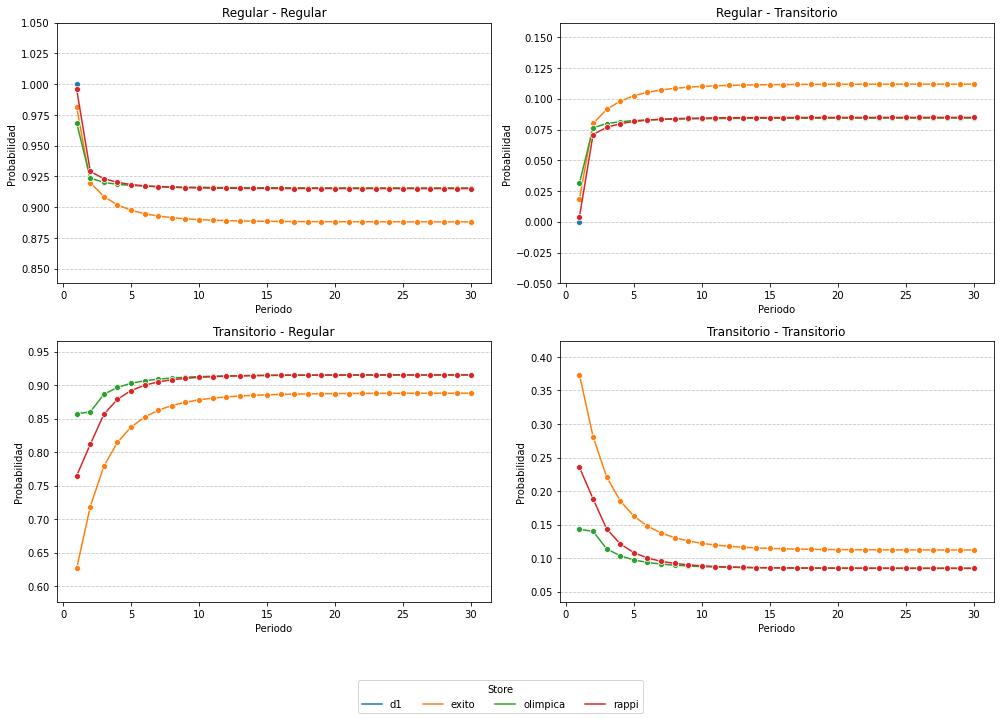

In [15]:
# Define probabilities to plot
probabilities = ['Mean_P_11', 'Mean_P_12', 'Mean_P_21', 'Mean_P_22']
titles = ['Regular → Regular', 'Regular → Temporary', 'Temporary → Regular', 'Temporary → Temporary']

plt.figure(figsize=(14, 10))

# Initialize variables for the legend
handles, labels = None, None

# Loop through probabilities and create subplots
for i, prob in enumerate(probabilities):
    ax = plt.subplot(2, 2, i + 1)
    plot = sns.lineplot(
        data=matrix_stores,
        x='period',
        y=prob,
        hue='tienda',
        marker='o'
    )
    plt.title(titles[i], fontsize=12)
    plt.xlabel('Period', fontsize=10)
    plt.ylabel('Probability', fontsize=10)
    
    # Dynamically adjust y-axis limits for better visibility of changes
    y_min = matrix_stores[prob].min() - 0.05
    y_max = matrix_stores[prob].max() + 0.05
    plt.ylim(y_min, y_max)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Capture the handles and labels from the first plot
    if handles is None and labels is None:
        handles, labels = ax.get_legend_handles_labels()
    
    # Remove legends from individual subplots
    ax.get_legend().remove()

# Add a single legend below all plots
plt.figlegend(handles, labels, title='Store', loc='lower center', fontsize=10, ncol=len(labels))
plt.subplots_adjust(bottom=0.2)  # Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Reserve space at the bottom for the legend

# Save the plot as a high-resolution image (optional)
plt.savefig(fig_dir + 'transition_probabilities_regular.png', dpi=300, bbox_inches='tight')

plt.show()

In [16]:
pt = "reference"
matrix_stores = matrixdf.groupby(["tienda", "period"]).apply(lambda x: pd.Series({
    'Mean_P_11': x["P_11_"+ pt].mean(),
    'Mean_P_12': x["P_12_"+ pt].mean(),
    'Mean_P_21': x["P_21_"+ pt].mean(),
    'Mean_P_22': x["P_22_"+ pt].mean(),
    'Median_P_11': x["P_11_"+ pt].median(),
    'Median_P_12': x["P_12_"+ pt].median(),
    'Median_P_21': x["P_21_"+ pt].median(),
    'Median_P_22': x["P_22_"+ pt].median()
}))

In [17]:
matrix_stores

Mean_P_11  Mean_P_12  Mean_P_21  Mean_P_22  Median_P_11  \
tienda period                                                            
C     1        0.989789   0.010211   0.901852   0.098148     0.982456   
       2        0.979790   0.020210   0.922351   0.077649     0.982149   
       3        0.978649   0.021351   0.943508   0.056492     0.982143   
       4        0.977965   0.022035   0.956057   0.043943     0.982143   
       5        0.977544   0.022456   0.963749   0.036251     0.982143   
...                  ...        ...        ...        ...          ...   
B  26       0.883519   0.116481   0.879057   0.120943     0.913043   
       27       0.883375   0.116625   0.879057   0.120943     0.913043   
       28       0.883236   0.116764   0.879057   0.120943     0.913043   
       29       0.883101   0.116899   0.879057   0.120943     0.913043   
       30       0.882970   0.117030   0.879057   0.120943     0.913043   

               Median_P_12  Median_P_21  Median_P_22  
tienda period                                         
C     1          0.017544     1.000000     0.000000  
       2          0.017851     0.981818     0.018182  
       3          0.017857     0.982149     0.017851  
       4          0.017857     0.982143     0.017857  
       5          0.017857     0.982143     0.017857  
...                    ...          ...          ...  
B  26         0.086957     0.913043     0.086957  
       27         0.086957     0.913043     0.086957  
       28         0.086957     0.913043     0.086957  
       29         0.086957     0.913043     0.086957  
       30         0.086957     0.913043     0.086957  

[120 rows x 8 columns]

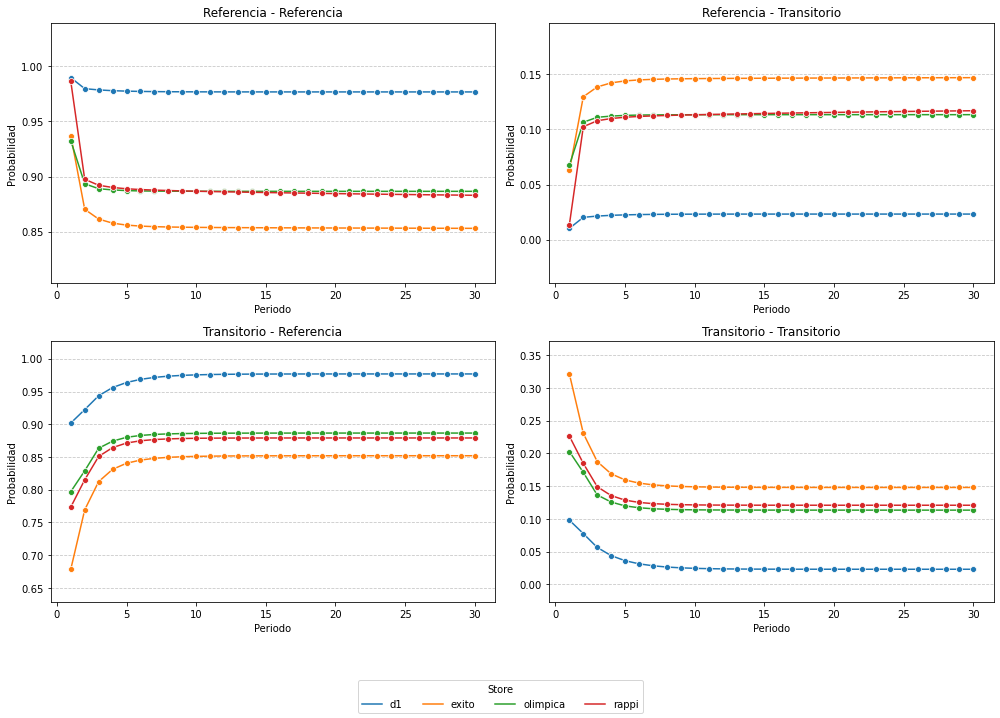

In [21]:
# Define probabilities to plot
probabilities = ['Mean_P_11', 'Mean_P_12', 'Mean_P_21', 'Mean_P_22']
pt = "reference"
matrix_stores = matrixdf.groupby(["tienda", "period"]).apply(lambda x: pd.Series({
    'Mean_P_11': x["P_11_"+ pt].mean(),
    'Mean_P_12': x["P_12_"+ pt].mean(),
    'Mean_P_21': x["P_21_"+ pt].mean(),
    'Mean_P_22': x["P_22_"+ pt].mean(),
    'Median_P_11': x["P_11_"+ pt].median(),
    'Median_P_12': x["P_12_"+ pt].median(),
    'Median_P_21': x["P_21_"+ pt].median(),
    'Median_P_22': x["P_22_"+ pt].median()
}))

titles = ['Reference → Reference', 'Reference → Temporary', 'Temporary → Reference', 'Temporary → Temporary']

plt.figure(figsize=(14, 10))

# Initialize variables for the legend
handles, labels = None, None

# Loop through probabilities and create subplots
for i, prob in enumerate(probabilities):
    ax = plt.subplot(2, 2, i + 1)
    plot = sns.lineplot(
        data=matrix_stores,
        x='period',
        y=prob,
        hue='tienda',
        marker='o'
    )
    plt.title(titles[i], fontsize=12)
    plt.xlabel('Period', fontsize=10)
    plt.ylabel('Probability', fontsize=10)
    
    # Dynamically adjust y-axis limits for better visibility of changes
    y_min = matrix_stores[prob].min() - 0.05
    y_max = matrix_stores[prob].max() + 0.05
    plt.ylim(y_min, y_max)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Capture the handles and labels from the first plot
    if handles is None and labels is None:
        handles, labels = ax.get_legend_handles_labels()
    
    # Remove legends from individual subplots
    ax.get_legend().remove()

# Add a single legend below all plots
plt.figlegend(handles, labels, title='Store', loc='lower center', fontsize=10, ncol=len(labels))
plt.subplots_adjust(bottom=0.2)  # Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Reserve space at the bottom for the legend

# Save the plot as a high-resolution image (optional)
plt.savefig(fig_dir + 'transition_probabilities_reference.png', dpi=300, bbox_inches='tight')

plt.show()

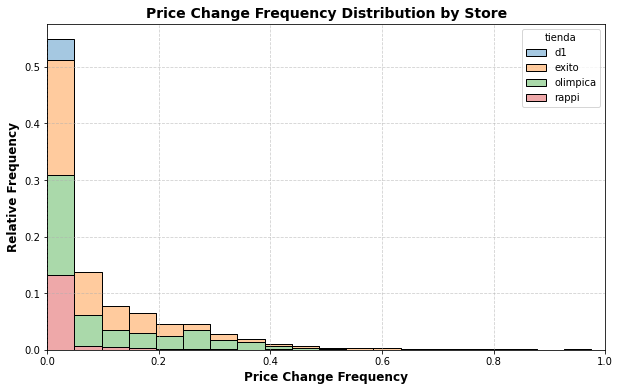

In [62]:
# Crear identificador único de producto (tienda + descripción)
data['producto'] = data['tienda'] + ' - ' + data['descripcion']

# Crear el histograma
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data, 
    x="Price Change Fr", 
    hue="tienda", 
    multiple="stack",  # Para apilar las tiendas
    bins=20,  # Número de barras
    stat="probability",  # Frecuencia relativa
    alpha=0.4,  # Transparencia
    edgecolor="black"
)

# Personalización del gráfico
plt.xlim(0, 1)  # La frecuencia de cambio de precio está entre 0 y 1
plt.xlabel("Price Change Frequency", fontsize=12, weight="bold")
plt.ylabel("Relative Frequency", fontsize=12, weight="bold")
plt.title("Price Change Frequency Distribution by Store", fontsize=14, weight="bold")
#plt.legend(title="Tienda", fontsize=12, title_fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)

# Save the plot as a high-resolution image (optional)
plt.savefig(fig_dir + 'histogram_change_frequency_posted.png', dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()

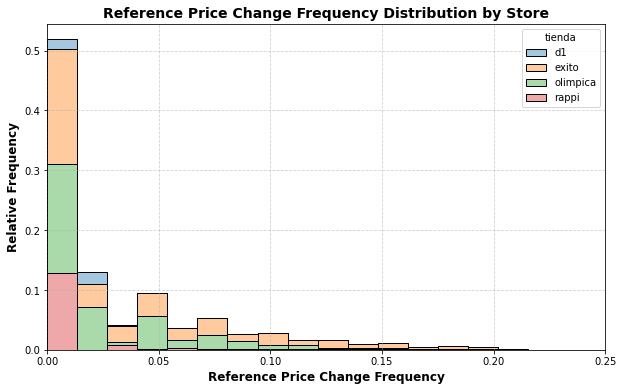

In [78]:
# Crear identificador único de producto (tienda + descripción)
data['producto'] = data['tienda'] + ' - ' + data['descripcion']

# Crear el histograma
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data, 
    x="RPE Change Fr", 
    hue="tienda", 
    multiple="stack",  # Para apilar las tiendas
    bins=20,  # Número de barras
    stat="probability",  # Frecuencia relativa
    alpha=0.4,  # Transparencia
    edgecolor="black"
)

# Personalización del gráfico
plt.xlim(0, 0.25)  # La frecuencia de cambio de precio está entre 0 y 1
plt.xlabel("Reference Price Change Frequency", fontsize=12, weight="bold")
plt.ylabel("Relative Frequency", fontsize=12, weight="bold")
plt.title("Reference Price Change Frequency Distribution by Store", fontsize=14, weight="bold")
#plt.legend(title="Tienda", fontsize=12, title_fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)

# Save the plot as a high-resolution image (optional)
plt.savefig(fig_dir + 'histogram_change_frequency_reference.png', dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()

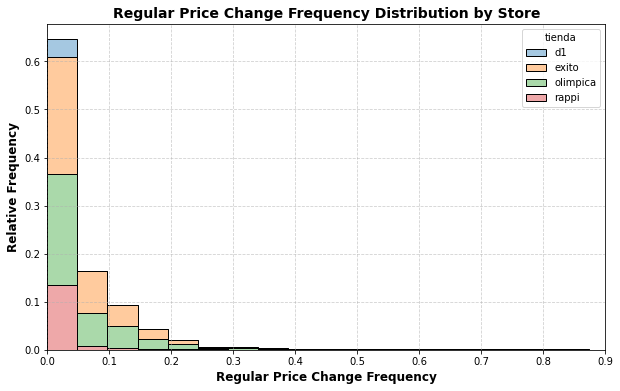

In [82]:
# Crear identificador único de producto (tienda + descripción)
data['producto'] = data['tienda'] + ' - ' + data['descripcion']

# Crear el histograma
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data, 
    x="RPN Change Fr", 
    hue="tienda", 
    multiple="stack",  # Para apilar las tiendas
    bins=20,  # Número de barras
    stat="probability",  # Frecuencia relativa
    alpha=0.4,  # Transparencia
    edgecolor="black"
)

# Personalización del gráfico
plt.xlim(0, 0.9)  # La frecuencia de cambio de precio está entre 0 y 1
plt.xlabel("Regular Price Change Frequency", fontsize=12, weight="bold")
plt.ylabel("Relative Frequency", fontsize=12, weight="bold")
plt.title("Regular Price Change Frequency Distribution by Store", fontsize=14, weight="bold")
#plt.legend(title="Tienda", fontsize=12, title_fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)

# Save the plot as a high-resolution image (optional)
plt.savefig(fig_dir + 'histogram_change_frequency_regular.png', dpi=300, bbox_inches='tight')

# Mostrar gráfico
plt.show()